## PyTorch Workflow

Book : https://www.learnpytorch.io/01_pytorch_workflow/
Questions : https://github.com/mrdbourke/pytorch-deep-learning/discussions

# Topics
* Data (prep and load)
* Build model
* Fitting the model to data (training)
* Make predictions and evaluate a model (inference)
* save and load a model
* connect everything together

In [1]:
import torch
from torch import nn #PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

#PyTorch Version
torch.__version__

'2.6.0+cu126'

## 1. Data (Prep and Load)

Data can be almost anything in ML
* Excel sheet
* Images
* Videos
* Audio
* DNA
* Text

ML is a game of 2 parts :
1. Get data into a numberical representation
2. Build a model to learn patterns in that numerical representation

In [2]:
# Test out linear regression formula ( y = a + bx )
# a = bias
# b = weight
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1) # Can comment out unsqueeze
y = bias + (weight * X)

print(X[:10], len(X), X.shape)
print(y[:10], len(y))


tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 50 torch.Size([50, 1])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]]) 50


### Splitting data into training and test sets (IMPORTANT!!)

1. Training set
The model learns from this data (like the course materials you study during the semester) ~ 60-80% `Always used`
2. Validation set
The model gets tuned on this data (like the practice exam you take before the final exam). ~ 10-20% `Often used`
3. Testing set
The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester). ~ 10-20% `Always used`

In [3]:
# Create a training split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualize Data

In [4]:
def plot_predictions(train_data = X_train, 
                     train_labels = y_train,
                     test_data = X_test, 
                     test_labels = y_test, 
                     predictions = None):
    """
    Plots training data, test data and compares predictions
    """ 

    plt.figure(figsize = (10, 7))

    #Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label = "Training data")

    #Plot test data in red
    plt.scatter(test_data, test_labels, c='g', s=4, label = "Testing data")

    #Are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label = "Predictions")

    #Show the legend (show our labels on the math plot)
    plt.legend(prop={"size" : 14})

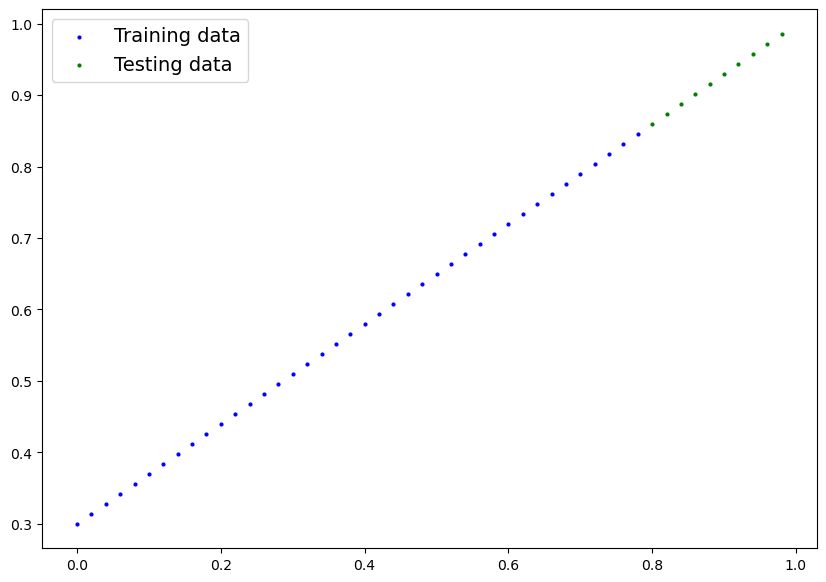

In [5]:
plot_predictions()

## 2. Build Model
Might require OOP in Python (still similar to C++)

In [6]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(1, 
                                               requires_grad=True,
                                               dtype = torch.float))

        self.bias = nn.Parameter(torch.rand(1, 
                                            requires_grad = True,
                                            dtype = torch.float))
        
        #Forward method to define the computation in the model
    def forward(self, x: torch.tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weight * x + self.bias

### PyTorch model building essentials
* torch.nn - contains all of the buildings for computational graphs (same thing as neural network)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizer s in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this function defines what happend in the forward computation

### Checking the contents of PyTorch models -> use `.parameters()`

In [7]:
#Create random seed
torch.manual_seed(42)

#Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#Check out parameters
print(list(model_0.parameters()))
print(model_0.state_dict())

[Parameter containing:
tensor([0.8823], requires_grad=True), Parameter containing:
tensor([0.9150], requires_grad=True)]
OrderedDict({'weight': tensor([0.8823]), 'bias': tensor([0.9150])})


### Predict Data with Function torch.inference_mode() -> predicts and do not save gradients for our data (makes python run faster)

In [8]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [9]:
y_preds = model_0(X_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

In [10]:
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

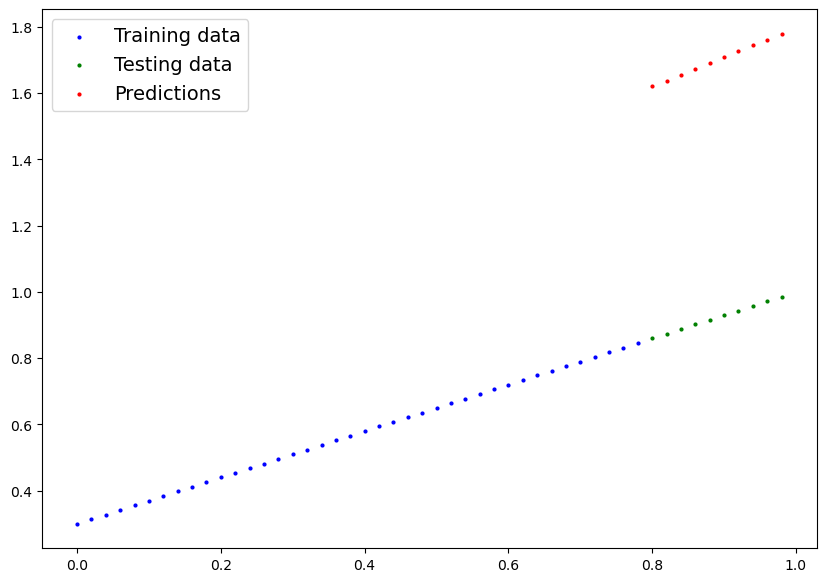

In [11]:
plot_predictions(predictions=y_preds)

### 3. Train model
Train our model to move from some unknown parameters (may be random) to some known parameters
In other words, from poor representation of data to a better one
One such way is to use a `loss function`
* Note : Loss function may also be called cost function or criterion.

Things we need to train :
* **Loss function** : function to measure how wrong your model's predictions are to the ideal outputs, lower is better
* **Optimizer** : Takes into account the loss of a model and adjusts the model's parameter (ex : weight & bias) to minimize loss function

In PyTorch normally we need :
* Training loop
* Testing loop

In [12]:
#Check out model's parameters (parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weight', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [13]:
#Setup a loss function
loss_func = nn.L1Loss()

#Setup an optimizer (stochastic gradient descent / random gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01) #lr = learning rate (VERY IMPORTANT)

Each loss function and optimizer function are problem specific, refer to PyTorch documentary website

### Training Loop
0. Loop through the data : steps below
1. Forward pass / forward propagation (this involves data moving through out model's `forward()` functions) to make predictions on data
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss. `Backward Propagation`
5.  Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss. `Gradient Descent`

In [14]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [16]:
# An epoch is 1 loop through the data (this is a hyperparameter we set ourselves)
epochs = 100

# Step 0. Loop through the data
for epoch in range(epochs):
    #Set the model to training mode
    model_0.train() #train mode sets all parameters that requires gradient to require_grad = True

    #1. Forward pass
    y_pred = model_0(X_train)

    #2. Loss function
    loss = loss_func(y_pred, y_train)

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Perform back propagation on the loss with respect to the parameters of the model
    loss.backward()

    #5. Step the optimizer (perform gradient descent)
    optimizer.step() #By default the optimizer changes will accumulate in each call of this function
                     #So we need to use optimizer.zero_grad() to reset it

    #Testing the model
    #Set the model to eval mode (turns off gradient, unused for testing)
    model_0.eval()
    
    #Turn on inference mode to turn off more unused stuff
    with torch.inference_mode():
        #1. Do the forward pass
        test_pred = model_0(X_test)

        #2. Calculate the loss
        test_loss = loss_func(test_pred, y_test)

    #Print
    print(f"Epoch : {epoch} | Train loss : {loss : 4f} | Test loss : {test_loss : 4f}")

Epoch : 0 | Train loss :  0.674568 | Test loss :  0.750282
Epoch : 1 | Train loss :  0.663047 | Test loss :  0.736811
Epoch : 2 | Train loss :  0.651526 | Test loss :  0.723340
Epoch : 3 | Train loss :  0.640005 | Test loss :  0.709869
Epoch : 4 | Train loss :  0.628484 | Test loss :  0.696398
Epoch : 5 | Train loss :  0.616963 | Test loss :  0.682927
Epoch : 6 | Train loss :  0.605442 | Test loss :  0.669456
Epoch : 7 | Train loss :  0.593921 | Test loss :  0.655985
Epoch : 8 | Train loss :  0.582400 | Test loss :  0.642514
Epoch : 9 | Train loss :  0.570879 | Test loss :  0.629043
Epoch : 10 | Train loss :  0.559358 | Test loss :  0.615572
Epoch : 11 | Train loss :  0.547837 | Test loss :  0.602101
Epoch : 12 | Train loss :  0.536316 | Test loss :  0.588630
Epoch : 13 | Train loss :  0.524795 | Test loss :  0.575159
Epoch : 14 | Train loss :  0.513274 | Test loss :  0.561688
Epoch : 15 | Train loss :  0.501753 | Test loss :  0.548217
Epoch : 16 | Train loss :  0.490232 | Test loss : 

In [19]:
with torch.inference_mode() :
    y_preds = model_0(X_test)
y_preds

tensor([[0.8530],
        [0.8669],
        [0.8808],
        [0.8946],
        [0.9085],
        [0.9224],
        [0.9363],
        [0.9501],
        [0.9640],
        [0.9779]])

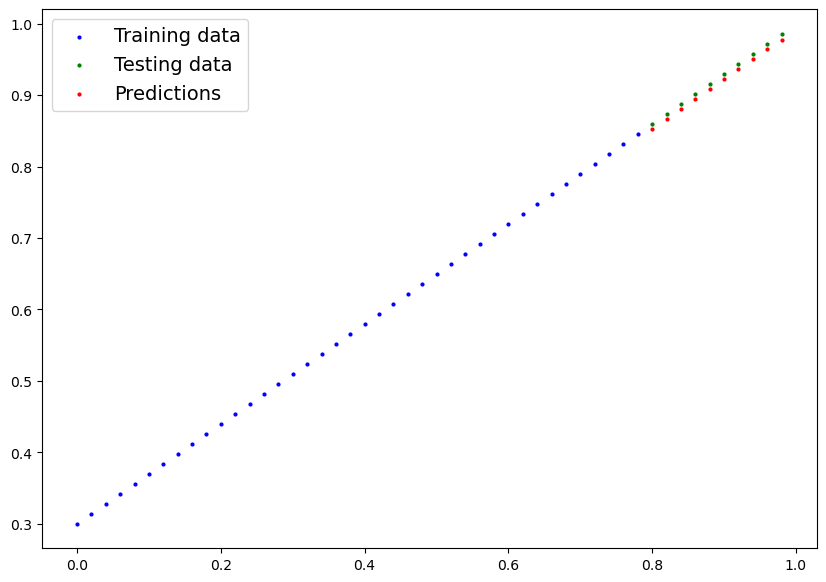

In [20]:
plot_predictions(predictions=y_preds)